In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load S&P500 data
sp500 = pd.read_excel("S&P 500.xlsx")

# Load JPMorgan data
jpm = pd.read_excel("JP morgan Final.xlsx")

# Load Citigroup data
citi = pd.read_excel("Citi Group Inc.xlsx")

# Load VIX data
vix = pd.read_excel("CBOEVIXCLS.xlsx", sheet_name="Daily, Close")

# Load TED Spread
ted = pd.read_excel("TEDRATE.xlsx")

In [5]:
# Convert date columns
sp500['Date'] = pd.to_datetime(sp500['Date'])
jpm['Date'] = pd.to_datetime(jpm['Date'])
citi['Date'] = pd.to_datetime(citi['Date'])
vix['date'] = pd.to_datetime(vix['date'])

# Rename columns
vix.rename(columns={"date":"Date"}, inplace=True)

# Sort data
sp500 = sp500.sort_values("Date")
jpm = jpm.sort_values("Date")
citi = citi.sort_values("Date")
vix = vix.sort_values("Date")

In [7]:
data = sp500.merge(jpm, on="Date")
data = data.merge(citi, on="Date")
data = data.merge(vix, on="Date")
data = data.merge(ted, on="Date")

data.head()

,Date,S&P 500,JP MORGAN,citigroup,VIXCLS,TEDRATE
0,2007-12-17,1445.90,44.53,69.53,24.52,1.93
1,2007-12-18,1454.98,43.90,69.53,22.64,1.95
2,2007-12-19,1453.00,43.98,69.03,21.68,2.06
3,2007-12-20,1460.12,43.33,69.53,20.58,2.03
4,2007-12-21,1484.46,44.11,68.03,18.47,1.94


In [8]:
# Make column names lowercase and remove extra spaces
data.columns = data.columns.str.lower().str.strip()

# Calculate log S&P 500 return
data['SP500_Return'] = np.log(data['s&p 500'] / data['s&p 500'].shift(1))

# Calculate log returns for JP MORGAN
data['jpm_return'] = np.log(data['jp morgan'] / data['jp morgan'].shift(1))

# Citigroup log return
data['CITI_Return'] = np.log(data['citigroup'] / data['citigroup'].shift(1))

# Remove missing values
data = data.dropna()

data.head()

,date,s&p 500,jp morgan,citigroup,vixcls,tedrate,SP500_Return,jpm_return,CITI_Return
1,2007-12-18,1454.98,43.90,69.53,22.64,1.95,0.006260,-0.014249,0.000000
2,2007-12-19,1453.00,43.98,69.03,21.68,2.06,-0.001362,0.001821,-0.007217
3,2007-12-20,1460.12,43.33,69.53,20.58,2.03,0.004888,-0.014890,0.007217
4,2007-12-21,1484.46,44.11,68.03,18.47,1.94,0.016532,0.017841,-0.021810
6,2007-12-27,1476.27,43.64,68.03,20.26,1.74,-0.014385,-0.029354,0.000000


In [11]:
stats = data[['SP500_Return','jpm_return','CITI_Return','vixcls']].describe()
print(stats)

       SP500_Return  jpm_return  CITI_Return      vixcls
count    646.000000  646.000000   646.000000  646.000000
mean      -0.000360   -0.000072     0.000264   28.996099
std        0.020142    0.122415     0.269141   12.237022
min       -0.105686   -0.576531    -1.274960   15.450000
25%       -0.008745   -0.030948    -0.050337   21.310000
50%        0.000493   -0.000774     0.000000   24.760000
75%        0.008000    0.030051     0.048796   31.637500
max        0.102457    0.722584     1.185689   80.860000


In [10]:
corr = data[['SP500_Return','jpm_return','CITI_Return','vixcls']].corr()
print(corr)

              SP500_Return  jpm_return  CITI_Return    vixcls
SP500_Return      1.000000    0.235208    -0.106079 -0.175374
jpm_return        0.235208    1.000000    -0.366026 -0.032422
CITI_Return      -0.106079   -0.366026     1.000000  0.023459
vixcls           -0.175374   -0.032422     0.023459  1.000000


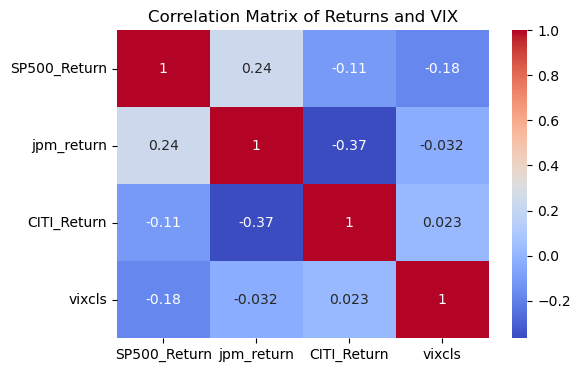

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(data[['SP500_Return','jpm_return','CITI_Return','vixcls']].corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix of Returns and VIX")
plt.show()

In [ ]:
##Plot the Market Behaviour

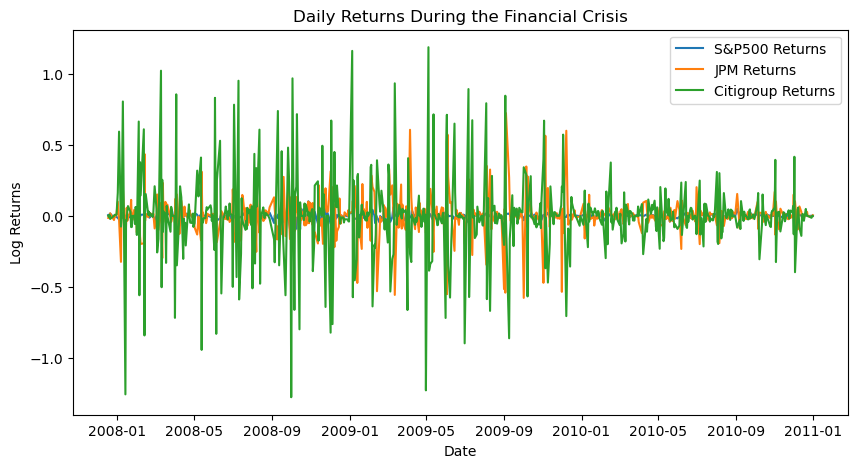

In [14]:
plt.figure(figsize=(10,5))
plt.plot(data['date'], data['SP500_Return'], label='S&P500 Returns')
plt.plot(data['date'], data['jpm_return'], label='JPM Returns')
plt.plot(data['date'], data['CITI_Return'], label='Citigroup Returns')
plt.legend()
plt.title("Daily Returns During the Financial Crisis")
plt.xlabel("Date")
plt.ylabel("Log Returns")
plt.show()

In [15]:
##Plot VIX (Market Fear Indicator)

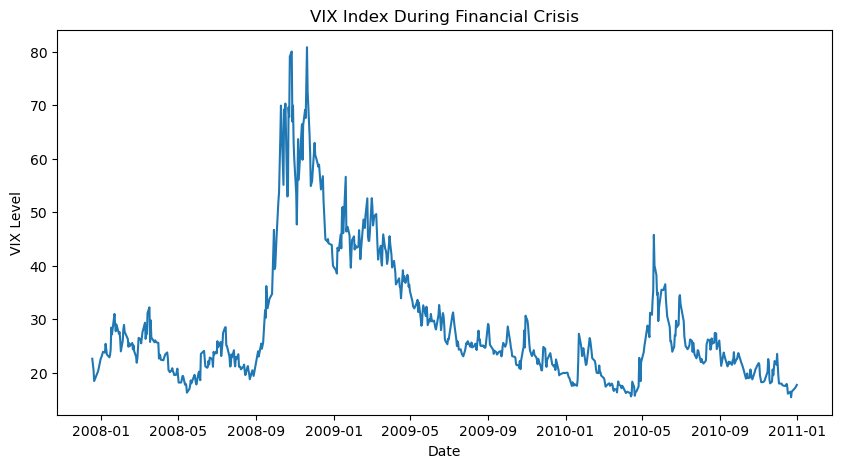

In [17]:
plt.figure(figsize=(10,5))
plt.plot(data['date'], data['vixcls'])
plt.title("VIX Index During Financial Crisis")
plt.xlabel("Date")
plt.ylabel("VIX Level")
plt.show()

In [18]:
##Plot TED Spread (Liquidity Risk)

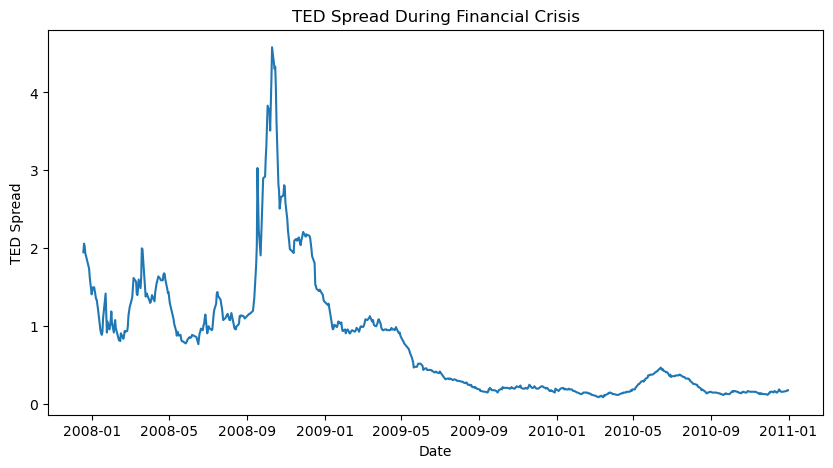

In [19]:
plt.figure(figsize=(10,5))
plt.plot(data['date'], data['tedrate'])
plt.title("TED Spread During Financial Crisis")
plt.xlabel("Date")
plt.ylabel("TED Spread")
plt.show()

In [20]:
##Calculate Value at Risk (VaR)
confidence = 0.95

VaR_SP500 = np.percentile(data['SP500_Return'], 5)
VaR_JPM = np.percentile(data['jpm_return'], 5)
VaR_CITI = np.percentile(data['CITI_Return'], 5)

print("VaR S&P500:", VaR_SP500)
print("VaR JPM:", VaR_JPM)
print("VaR Citigroup:", VaR_CITI)

VaR S&P500: -0.03245882918238408
VaR JPM: -0.17492107337597293
VaR Citigroup: -0.4747064941974643


In [21]:
##Calculate Expected Shortfall (ES)
ES_SP500 = data['SP500_Return'][data['SP500_Return'] <= VaR_SP500].mean()
ES_JPM = data['jpm_return'][data['jpm_return'] <= VaR_JPM].mean()
ES_CITI = data['CITI_Return'][data['CITI_Return'] <= VaR_CITI].mean()

print("ES S&P500:", ES_SP500)
print("ES JPM:", ES_JPM)
print("ES Citigroup:", ES_CITI)

ES S&P500: -0.05211587753922801
ES JPM: -0.30865182139163405
ES Citigroup: -0.7135686857521288
